<a href="https://colab.research.google.com/github/4551kiet-999/GOOGLE-PAGE-RANK-MINI/blob/main/Back%20end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

              GOOGLE PAGERANK MINI (B2)

Project: Google PageRank Mini
Pages: A, B, C, D, E
Damping Factor: 0.85

1. LINK STRUCTURE
A -> B, C
B -> C, D
C -> A
D -> C, E
E -> A, D

2. TRANSITION MATRIX M
     A    B    C    D    E
A  0.0  0.0  1.0  0.0  0.5
B  0.5  0.0  0.0  0.0  0.0
C  0.5  0.5  0.0  0.5  0.0
D  0.0  0.5  0.0  0.0  0.5
E  0.0  0.0  0.0  0.5  0.0

Meaning:
M[i,j] = probability of moving FROM page j TO page i.

3. GOOGLE PAGERANK MATRIX G
       A      B     C      D      E
A  0.030  0.030  0.88  0.030  0.455
B  0.455  0.030  0.03  0.030  0.030
C  0.455  0.455  0.03  0.455  0.030
D  0.030  0.455  0.03  0.030  0.455
E  0.030  0.030  0.03  0.455  0.030

4. POWER ITERATION
Formula:
        r(k+1) = G × r(k)

Initial PageRank:
[0.2 0.2 0.2 0.2 0.2]

Iterations: 58
Final Error: 7.393874401628864e-11

PageRank values during iterations:
                  A         B         C         D         E
Iteration                                                  
0          0.200000  0.

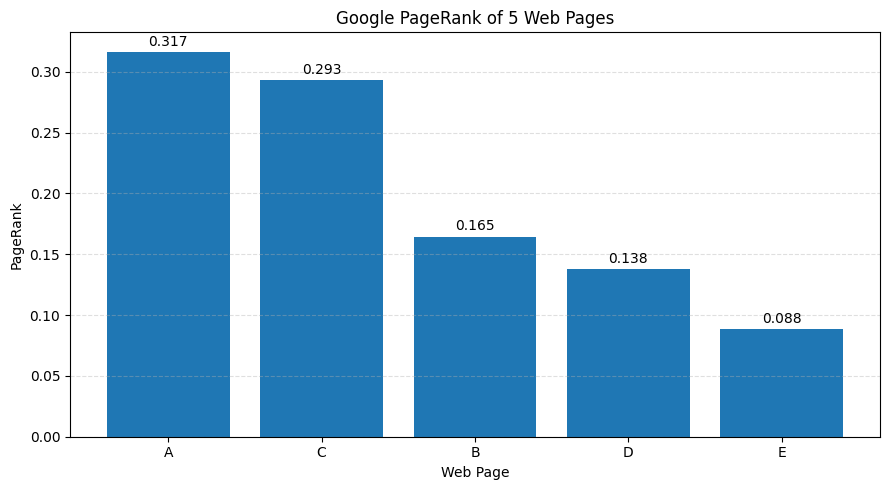

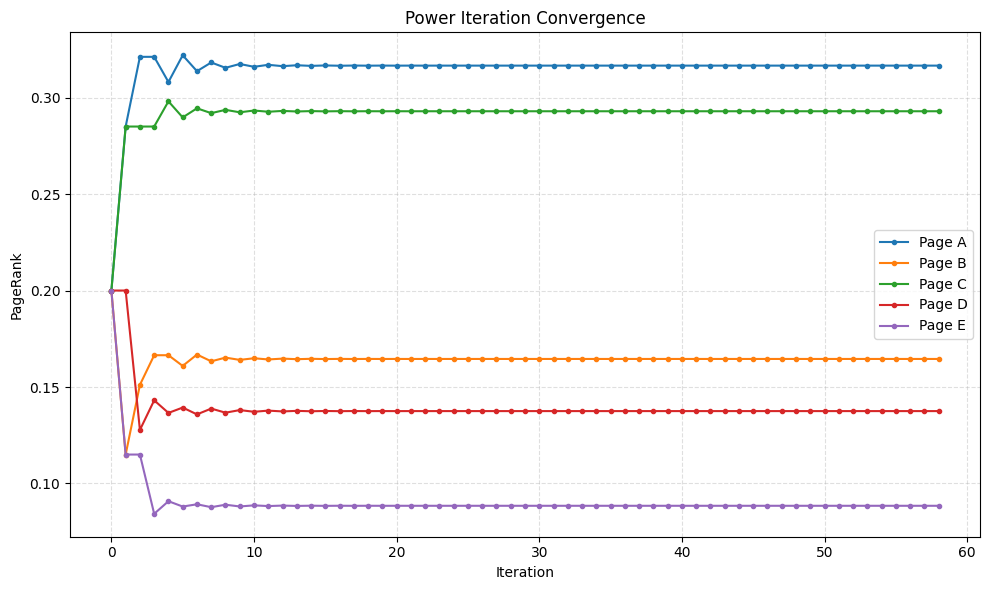

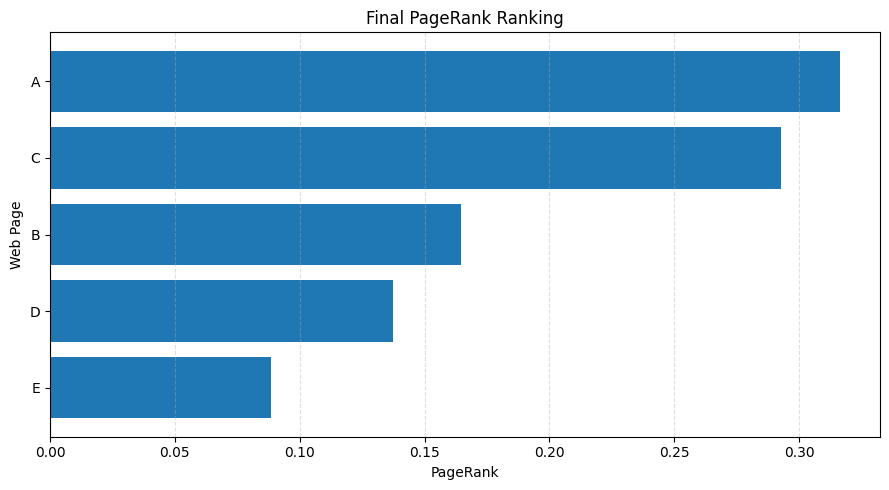


                  PROJECT SUMMARY

Problem:
Create a small web of 5 pages and determine which page
is the most important using Google's PageRank idea.

Mathematical Concept:
1. Build the transition matrix M.
2. Build the Google matrix G.
3. Start with an equal PageRank vector.
4. Apply power iteration repeatedly.
5. Stop when the vector converges.
6. The final vector is the steady-state eigenvector.
7. The corresponding eigenvalue is 1.

Real-World Context:
Google's PageRank algorithm uses the mathematical idea
of eigenvectors to rank web pages.

Power Method:
        r(k+1) = G r(k)

Eigenvector Equation:
        G r = r

Equivalent Eigenvalue Equation:
        G r = 1r

Hence:
        Eigenvalue = 1
        Eigenvector = PageRank vector

                 PROJECT COMPLETED


In [8]:

# ============================================================
# GOOGLE PAGERANK MINI (B2)
# B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. INPUT CONFIGURATION
# ------------------------------------------------------------

# Five web pages
pages = ["A", "B", "C", "D", "E"]

# Links between pages
# A -> B, C
# B -> C, D
# C -> A
# D -> C, E
# E -> A, D

links = {
    "A": ["B", "C"],
    "B": ["C", "D"],
    "C": ["A"],
    "D": ["C", "E"],
    "E": ["A", "D"]
}

# PageRank parameters
damping = 0.85
tolerance = 1e-10
max_iterations = 100


# ------------------------------------------------------------
# 2. BUILD TRANSITION MATRIX
# ------------------------------------------------------------

def build_transition_matrix(pages, links):

    n = len(pages)
    index = {page: i for i, page in enumerate(pages)}

    # Start with zero matrix
    M = np.zeros((n, n))

    for source in pages:

        source_index = index[source]
        destinations = links.get(source, [])

        # If a page has no outgoing links,
        # distribute probability equally to all pages.
        if len(destinations) == 0:

            M[:, source_index] = 1 / n

        else:

            probability = 1 / len(destinations)

            for destination in destinations:

                destination_index = index[destination]

                M[destination_index, source_index] = probability

    return M


# ------------------------------------------------------------
# 3. GOOGLE PAGERANK MATRIX
# ------------------------------------------------------------

def build_google_matrix(M, damping):

    n = M.shape[0]

    # Matrix containing all ones
    J = np.ones((n, n))

    # Google PageRank matrix
    #
    # G = dM + (1-d)/n * J
    #
    # d = damping factor
    G = damping * M + ((1 - damping) / n) * J

    return G


# ------------------------------------------------------------
# 4. POWER ITERATION
# ------------------------------------------------------------

def power_iteration(G, tolerance, max_iterations):

    n = G.shape[0]

    # Initial PageRank:
    # Every page starts with equal probability.
    rank = np.ones(n) / n

    history = [rank.copy()]

    for iteration in range(1, max_iterations + 1):

        # Power method:
        #
        # r(k+1) = G r(k)
        #
        new_rank = G @ rank

        # Normalize to make sure total probability = 1
        new_rank = new_rank / np.sum(new_rank)

        history.append(new_rank.copy())

        # Calculate error
        error = np.linalg.norm(
            new_rank - rank,
            ord=1
        )

        # Check convergence
        if error < tolerance:

            return (
                new_rank,
                iteration,
                np.array(history),
                error
            )

        rank = new_rank

    return (
        rank,
        max_iterations,
        np.array(history),
        error
    )


# ------------------------------------------------------------
# 5. EIGENVALUE VERIFICATION
# ------------------------------------------------------------

def calculate_eigenvector(G):

    # Find eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(G)

    # Find eigenvalue closest to 1
    index = np.argmin(
        np.abs(eigenvalues - 1)
    )

    eigenvalue = eigenvalues[index]

    eigenvector = np.real(
        eigenvectors[:, index]
    )

    # Make vector positive
    if np.sum(eigenvector) < 0:
        eigenvector = -eigenvector

    # Normalize
    eigenvector = (
        eigenvector /
        np.sum(eigenvector)
    )

    return eigenvalue, eigenvector


# ------------------------------------------------------------
# 6. RUN THE COMPLETE MATHEMATICAL MODEL
# ------------------------------------------------------------

M = build_transition_matrix(
    pages,
    links
)

G = build_google_matrix(
    M,
    damping
)

pagerank, iterations, history, final_error = power_iteration(
    G,
    tolerance,
    max_iterations
)

eigenvalue, eigenvector = calculate_eigenvector(G)


# ------------------------------------------------------------
# 7. OUTPUT
# ------------------------------------------------------------

np.set_printoptions(
    precision=6,
    suppress=True
)

print("=" * 70)
print("              GOOGLE PAGERANK MINI (B2)")
print("=" * 70)

print("\nProject: Google PageRank Mini")
print("Pages:", ", ".join(pages))
print("Damping Factor:", damping)

print("\n" + "=" * 70)
print("1. LINK STRUCTURE")
print("=" * 70)

for page in pages:
    print(
        f"{page} -> "
        + ", ".join(links[page])
    )


# ------------------------------------------------------------
# TRANSITION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. TRANSITION MATRIX M")
print("=" * 70)

transition_df = pd.DataFrame(
    M,
    index=pages,
    columns=pages
)

print(
    transition_df.round(4).to_string()
)

print("\nMeaning:")
print("M[i,j] = probability of moving FROM page j TO page i.")


# ------------------------------------------------------------
# GOOGLE MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. GOOGLE PAGERANK MATRIX G")
print("=" * 70)

google_df = pd.DataFrame(
    G,
    index=pages,
    columns=pages
)

print(
    google_df.round(4).to_string()
)


# ------------------------------------------------------------
# POWER ITERATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. POWER ITERATION")
print("=" * 70)

print("Formula:")
print("        r(k+1) = G × r(k)")

print("\nInitial PageRank:")
print(
    np.ones(len(pages)) / len(pages)
)

print("\nIterations:", iterations)
print("Final Error:", final_error)


# ------------------------------------------------------------
# ITERATION TABLE
# ------------------------------------------------------------

iteration_df = pd.DataFrame(
    history,
    columns=pages
)

iteration_df.index.name = "Iteration"

print("\nPageRank values during iterations:")
print(
    iteration_df.round(6).to_string()
)


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

result = pd.DataFrame({
    "Page": pages,
    "PageRank": pagerank
})

result["Percentage"] = (
    result["PageRank"] * 100
)

result = result.sort_values(
    "PageRank",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("5. FINAL PAGERANK RESULT")
print("=" * 70)

print(
    result.to_string(
        index=False,
        formatters={
            "PageRank": "{:.6f}".format,
            "Percentage": "{:.2f}%".format
        }
    )
)


# ------------------------------------------------------------
# MOST IMPORTANT PAGE
# ------------------------------------------------------------

most_important = result.iloc[0]["Page"]
highest_rank = result.iloc[0]["PageRank"]

print("\n" + "=" * 70)
print("6. MOST IMPORTANT PAGE")
print("=" * 70)

print(
    f"Page {most_important} is the MOST IMPORTANT PAGE."
)

print(
    f"PageRank = {highest_rank:.6f}"
)


# ------------------------------------------------------------
# EIGENVALUE = 1 VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("7. EIGENVALUE VERIFICATION")
print("=" * 70)

print(
    f"Eigenvalue closest to 1 = "
    f"{eigenvalue.real:.10f}"
)

print("\nCorresponding eigenvector:")

for page, value in zip(
    pages,
    eigenvector
):

    print(
        f"Page {page}: {value:.6f}"
    )

print("\nMathematical relation:")
print("        G × r = r")
print("        G × r = 1 × r")

print("\nTherefore:")
print("Eigenvalue = 1")
print("Eigenvector = PageRank steady-state vector")


# ============================================================
# 8. VISUALIZATION 1 — PAGERANK BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    result["Page"],
    result["PageRank"]
)

plt.xlabel("Web Page")
plt.ylabel("PageRank")
plt.title("Google PageRank of 5 Web Pages")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for i, value in enumerate(
    result["PageRank"]
):

    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZATION 2 — POWER ITERATION CONVERGENCE
# ============================================================

plt.figure(figsize=(10, 6))

for i, page in enumerate(pages):

    plt.plot(
        history[:, i],
        marker="o",
        markersize=3,
        label=f"Page {page}"
    )

plt.xlabel("Iteration")
plt.ylabel("PageRank")

plt.title(
    "Power Iteration Convergence"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. VISUALIZATION 3 — FINAL RANKING
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    result["Page"][::-1],
    result["PageRank"][::-1]
)

plt.xlabel("PageRank")
plt.ylabel("Web Page")

plt.title(
    "Final PageRank Ranking"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("                  PROJECT SUMMARY")
print("=" * 70)

print("""
Problem:
Create a small web of 5 pages and determine which page
is the most important using Google's PageRank idea.

Mathematical Concept:
1. Build the transition matrix M.
2. Build the Google matrix G.
3. Start with an equal PageRank vector.
4. Apply power iteration repeatedly.
5. Stop when the vector converges.
6. The final vector is the steady-state eigenvector.
7. The corresponding eigenvalue is 1.

Real-World Context:
Google's PageRank algorithm uses the mathematical idea
of eigenvectors to rank web pages.

Power Method:
        r(k+1) = G r(k)

Eigenvector Equation:
        G r = r

Equivalent Eigenvalue Equation:
        G r = 1r

Hence:
        Eigenvalue = 1
        Eigenvector = PageRank vector
""")

print("=" * 70)
print("                 PROJECT COMPLETED")
print("=" * 70)